# 🗳️ Pronóstico intención de voto — Presidencia 2026

Aplica el modelo **ElasticNet con selección anidada** entrenado en `03_automl_seleccion.ipynb` para pronosticar la cuota de voto de:

| Candidato | id_candidato |
|---|---|
| **Iván Cepeda Castro** | `cepeda_ivan` |
| **Abelardo De la Espriella** | `delaespriella_abelardo` |

El modelo usa las **cuotas de interacciones digitales** (likes, comentarios, compartidos) como predictores, escaladas al logit del porcentaje de dominancia entre candidatos.

## Celda 1 — Setup

In [6]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV

# ── Rutas ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR     = Path(os.path.abspath(''))
RAIZ_DIR         = NOTEBOOK_DIR.parent
HERRAMIENTAS_DIR = RAIZ_DIR / 'Herramientas'
ELEC_DIR         = NOTEBOOK_DIR
RESULTADOS_DIR   = ELEC_DIR / 'resultados'

# Redes unificadas del modelo entrenado (datos 2023)
REDES_TRAIN  = HERRAMIENTAS_DIR / 'resultados' / 'redes_unificadas.csv'
# Redes unificadas de los candidatos 2026
REDES_2026   = RESULTADOS_DIR / 'presidencia2026_unificada.csv'
# Seguidores de los candidatos de entrenamiento
SEGUIDORES   = HERRAMIENTAS_DIR / 'resultados' / 'seguidores.csv'
# Excel con resultados electorales (para entrenamiento)
EXCEL_PATH   = RAIZ_DIR / 'Colombia' / 'Resultados electorales.xlsx'

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
AZUL, ROJO = '#1A2F6F', '#FF4B4B'

print(f'📁 Herramientas: {HERRAMIENTAS_DIR}')
print(f'📁 Resultados:   {RESULTADOS_DIR}')
print(f'📄 Redes train:  {"✅" if REDES_TRAIN.exists() else "❌"} {REDES_TRAIN.name}')
print(f'📄 Redes 2026:   {"✅" if REDES_2026.exists() else "❌ FALTA — ejecuta unificar_presidencia2026.py"}')
print(f'📄 Seguidores:   {"✅" if SEGUIDORES.exists() else "❌"} {SEGUIDORES.name}')
print(f'📄 Excel:        {"✅" if EXCEL_PATH.exists() else "❌"} {EXCEL_PATH.name}')

📁 Herramientas: c:\Users\juansoag\Downloads\Avances_tesis (modificado)\Herramientas
📁 Resultados:   c:\Users\juansoag\Downloads\Avances_tesis (modificado)\Elecciones presidencia 2026\resultados
📄 Redes train:  ✅ redes_unificadas.csv
📄 Redes 2026:   ✅
📄 Seguidores:   ✅ seguidores.csv
📄 Excel:        ✅ Resultados electorales.xlsx


## Celda 2 — Cargar datos de entrenamiento

Reproducimos exactamente las transformaciones de `03_automl_seleccion.ipynb`.

In [7]:
# ── Datos de entrenamiento ────────────────────────────────────────────────────
df_redes      = pd.read_csv(REDES_TRAIN,    sep=';', encoding='utf-8-sig')
df_electoral  = pd.read_excel(EXCEL_PATH, sheet_name='Candidatos E-26 ALC').rename(
                    columns={'ID Candidato': 'id_candidato'})
df_poblacion  = pd.read_excel(EXCEL_PATH, sheet_name='Población 2023 (DANE)')
df_seguidores = pd.read_csv(SEGUIDORES,     sep=';', encoding='utf-8-sig').fillna(0)

# Excluir municipios problemáticos
for ex in ['68547', '68081']:
    df_redes = df_redes[~df_redes['id_candidato'].str.contains(ex, na=False)]

# Merge
df = df_redes.merge(
        df_seguidores[['id_candidato','tiktok_followers','twitter_followers','facebook_followers']],
        on='id_candidato', how='left')
df = df.merge(
        df_electoral[['id_candidato','Candidato','Ganador','Votos']],
        on='id_candidato', how='left')
df['DIVIPOLA'] = df['id_candidato'].astype(str).str.split('-').str[1].str.zfill(5)

df_poblacion['DIVIPOLA'] = (
    pd.to_numeric(df_poblacion['DIVIPOLA'], errors='coerce')
      .fillna(0).astype(int).astype(str).str.zfill(5)
)
df = df.merge(df_poblacion[['DIVIPOLA','Población 2023']], on='DIVIPOLA', how='left')

print(f'Candidatos train: {df["id_candidato"].nunique()} | Municipios: {df["DIVIPOLA"].nunique()}')

Candidatos train: 120 | Municipios: 31


## Celda 3 — Feature engineering (mismo que el modelo original)

In [8]:
FOLLOWER_COL = {'Facebook': 'facebook_followers', 'Twitter': 'twitter_followers', 'TikTok': 'tiktok_followers'}

def prepare_lens_data(data, metric_col, lente='dominancia', platform=None):
    data = data.copy()
    if platform is not None:
        data = data[data['red_social'] == platform]
    if len(data) == 0 or metric_col not in data.columns:
        return pd.DataFrame()
    agg = data.groupby(['DIVIPOLA','id_candidato','Candidato','Ganador']).agg(
        metric_sum=(metric_col, 'sum'),
        n_posts=(metric_col, 'count'),
        votos=('Votos', 'first'),
        pob=('Población 2023', 'first')
    ).reset_index()
    if lente in ('totales', 'dominancia'):
        agg['v'] = agg['metric_sum']
    elif lente == 'por_post':
        agg['v'] = agg['metric_sum'] / agg['n_posts'].replace(0, np.nan)
    agg = agg.replace([np.inf, -np.inf], np.nan)
    agg['pct_metric'] = (agg['v'] / agg.groupby('DIVIPOLA')['v'].transform('sum')) * 100
    return agg[agg.groupby('DIVIPOLA')['v'].transform('sum') > 0]

def to_logit(p_pct, eps=1e-3):
    p = np.clip(p_pct / 100, eps, 1 - eps)
    return np.log(p / (1 - p))

combos = [
    ('likes',      'dominancia', 'f_likes_dom'),
    ('comentarios','dominancia', 'f_coment_dom'),
    ('compartidos','dominancia', 'f_compart_dom'),
    ('likes',      'por_post',   'f_likes_pp'),
    ('comentarios','por_post',   'f_coment_pp'),
    ('compartidos','por_post',   'f_compart_pp'),
]

b = prepare_lens_data(df, 'likes', 'dominancia', None)
b['total_votos'] = b.groupby('DIVIPOLA')['votos'].transform('sum')
b['vote_frac']   = (b['votos'] / b['total_votos']).clip(1e-4, 1 - 1e-4)
b['n_candidatos']= b.groupby('DIVIPOLA')['id_candidato'].transform('count')
b['log_pob']     = np.log(b['pob'].clip(lower=1))
base = b[['id_candidato','DIVIPOLA','Candidato','Ganador','vote_frac','n_candidatos','log_pob']].copy()

for tipo, lente, nombre in combos:
    d = prepare_lens_data(df, tipo, lente, None)[['id_candidato','pct_metric']]
    base = base.merge(d.rename(columns={'pct_metric': nombre}), on='id_candidato', how='left')

for nombre in [c[2] for c in combos]:
    base[nombre] = to_logit(base[nombre])

base['mod_likes_pob'] = base['f_likes_dom'] * (base['log_pob'] - base['log_pob'].mean())
base = base.dropna(subset=[c[2] for c in combos] + ['vote_frac', 'log_pob']).reset_index(drop=True)

DIGITAL = [c[2] for c in combos]
TERR    = ['n_candidatos', 'log_pob']
POOL    = DIGITAL + TERR + ['mod_likes_pob']

print(f'Filas train: {len(base)} | Municipios: {base["DIVIPOLA"].nunique()} | Features: {POOL}')

Filas train: 120 | Municipios: 31 | Features: ['f_likes_dom', 'f_coment_dom', 'f_compart_dom', 'f_likes_pp', 'f_coment_pp', 'f_compart_pp', 'n_candidatos', 'log_pob', 'mod_likes_pob']


## Celda 4 — Entrenar modelo ElasticNet (especificación ganadora)

La especificación con menor MAE en el notebook original es **"likes + moderador(pob)"** con:
- `f_likes_dom` (dominancia de likes en logit)
- `mod_likes_pob` (interacción likes × log_población)

In [9]:
# Especificación ganadora del modelo
FEATURES_MODELO = ['f_likes_dom', 'mod_likes_pob']

X_train = base[FEATURES_MODELO].values
y_train = base['vote_frac'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

model = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    alphas=np.logspace(-4, 1, 100),
    cv=5,
    max_iter=10000,
    random_state=42
)
model.fit(X_scaled, y_train)

print(f'Alpha óptimo: {model.alpha_:.6f}')
print(f'L1 ratio:     {model.l1_ratio_:.2f}')
print(f'Coeficientes: {dict(zip(FEATURES_MODELO, model.coef_))}')
print(f'Intercept:    {model.intercept_:.4f}')

Alpha óptimo: 0.047508
L1 ratio:     0.10
Coeficientes: {'f_likes_dom': np.float64(0.11094487554722374), 'mod_likes_pob': np.float64(0.02617757557188117)}
Intercept:    0.2583


## Celda 5 — Construir features para los candidatos 2026

In [10]:
if not REDES_2026.exists():
    raise FileNotFoundError(
        f'No se encuentra {REDES_2026}\n'
        f'Ejecuta primero: python unificar_presidencia2026.py'
    )

df26 = pd.read_csv(REDES_2026, sep=';', encoding='utf-8-sig')
print(f'Filas 2026: {len(df26)}')
print(df26['id_candidato'].value_counts())

# ─────────────────────────────────────────────────────────────────────────────
# Para la contienda presidencial, el 'DIVIPOLA' es un valor ficticio
# (los dos candidatos compiten en el mismo territorio: Colombia).
# Usamos un único ID de contienda: 'COL-00000-000'
# ─────────────────────────────────────────────────────────────────────────────
CONTIENDA = 'COL'
df26['DIVIPOLA'] = CONTIENDA

# Candidatos presentes
CANDIDATOS_2026 = [
    {'id_candidato': 'cepeda_ivan',            'nombre': 'Iván Cepeda Castro'},
    {'id_candidato': 'delaespriella_abelardo',  'nombre': 'Abelardo De la Espriella'},
]

# Calcular likes totales por candidato (dominancia)
totales = df26.groupby('id_candidato')['likes'].sum().reset_index()
totales.columns = ['id_candidato', 'total_likes']
grand_total = totales['total_likes'].sum()
totales['pct_likes_dom'] = (totales['total_likes'] / grand_total * 100).clip(0.01, 99.99)

# Calcular likes por post
por_post = df26.groupby('id_candidato').agg(
    sum_likes=('likes', 'sum'),
    n_posts=('likes', 'count')
).reset_index()
por_post['likes_pp'] = por_post['sum_likes'] / por_post['n_posts'].replace(0, np.nan)
total_likes_pp = por_post['likes_pp'].sum()
por_post['pct_likes_pp'] = (por_post['likes_pp'] / total_likes_pp * 100).clip(0.01, 99.99)

features_2026 = totales.merge(por_post[['id_candidato','pct_likes_pp']], on='id_candidato')
features_2026['f_likes_dom'] = to_logit(features_2026['pct_likes_dom'])
features_2026['f_likes_pp']  = to_logit(features_2026['pct_likes_pp'])

# Para mod_likes_pob usamos log(población de Colombia)
POB_COLOMBIA = 52_215_503   # DANE 2023 proyección
LOG_POB_MEAN_TRAIN = base['log_pob'].mean()  # media del conjunto de entrenamiento
log_pob_col = np.log(POB_COLOMBIA)
features_2026['mod_likes_pob'] = features_2026['f_likes_dom'] * (log_pob_col - LOG_POB_MEAN_TRAIN)

print('\nFeatures 2026:')
display(features_2026[['id_candidato','pct_likes_dom','f_likes_dom','mod_likes_pob']])

Filas 2026: 444
id_candidato
cepeda_ivan               255
delaespriella_abelardo    189
Name: count, dtype: int64

Features 2026:


,id_candidato,pct_likes_dom,f_likes_dom,mod_likes_pob
0,cepeda_ivan,77.621731,1.243757,5.437458
1,delaespriella_abelardo,22.378269,-1.243757,-5.437458


## Celda 6 — Pronóstico

In [11]:
X_2026 = features_2026[FEATURES_MODELO].values
X_2026_scaled = scaler.transform(X_2026)

pred_raw = model.predict(X_2026_scaled)
# Normalizar para que sumen 1 (son proporciones de votos)
pred_norm = np.clip(pred_raw, 0, 1)
pred_norm = pred_norm / pred_norm.sum()

resultados = features_2026[['id_candidato']].copy()
resultados['prediccion_raw']  = pred_raw
resultados['cuota_voto_pred'] = pred_norm
resultados['pct_voto_pred']   = (pred_norm * 100).round(2)

# Añadir nombre
nombre_map = {c['id_candidato']: c['nombre'] for c in CANDIDATOS_2026}
resultados['nombre'] = resultados['id_candidato'].map(nombre_map)
resultados = resultados.sort_values('pct_voto_pred', ascending=False).reset_index(drop=True)

# Baseline: proporcionalidad de likes
resultados['baseline_likes_pct'] = features_2026['pct_likes_dom'].values[::-1] if resultados['id_candidato'].iloc[0] != features_2026['id_candidato'].iloc[0] else features_2026['pct_likes_dom'].values

print('\n' + '='*55)
print('  PRONÓSTICO DE INTENCIÓN DE VOTO — PRESIDENCIA 2026')
print('='*55)
for _, row in resultados.iterrows():
    print(f"\n  👤 {row['nombre']}")
    print(f"     Modelo ElasticNet : {row['pct_voto_pred']:.1f}%")

print('\n' + '='*55)
winner = resultados.iloc[0]
print(f"  🏆 Favorito del modelo: {winner['nombre']} ({winner['pct_voto_pred']:.1f}%)")
print('='*55)

display(resultados)


  PRONÓSTICO DE INTENCIÓN DE VOTO — PRESIDENCIA 2026

  👤 Iván Cepeda Castro
     Modelo ElasticNet : 67.4%

  👤 Abelardo De la Espriella
     Modelo ElasticNet : 32.6%

  🏆 Favorito del modelo: Iván Cepeda Castro (67.4%)


,id_candidato,prediccion_raw,cuota_voto_pred,pct_voto_pred,nombre,baseline_likes_pct
0,cepeda_ivan,0.487407,0.673981,67.4,Iván Cepeda Castro,77.621731
1,delaespriella_abelardo,0.235770,0.326019,32.6,Abelardo De la Espriella,22.378269


## Celda 7 — Visualización

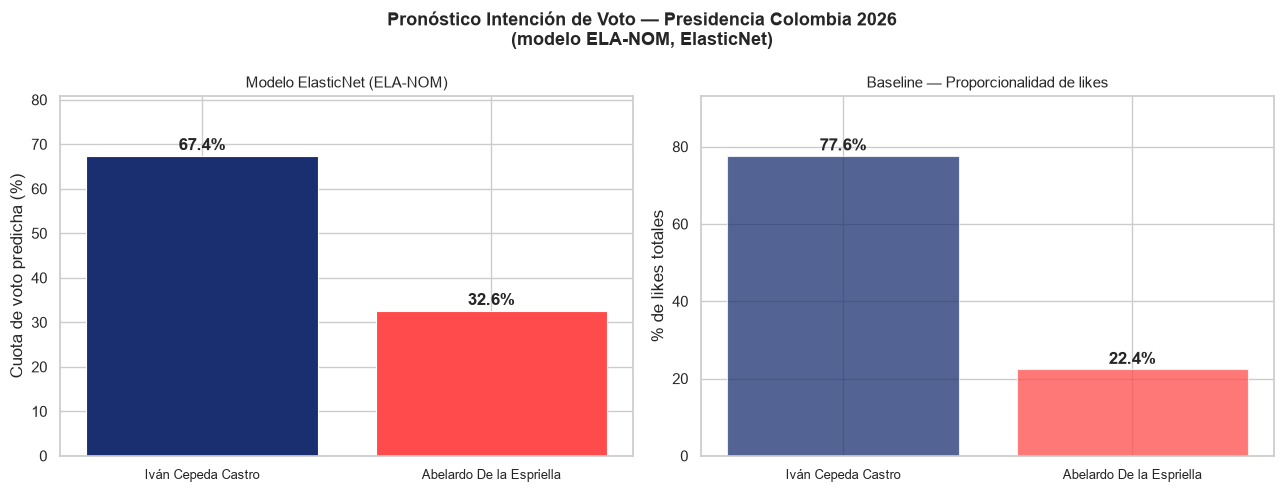


💾 Gráfico guardado en: c:\Users\juansoag\Downloads\Avances_tesis (modificado)\Elecciones presidencia 2026\resultados\pronostico_presidencia2026.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Pronóstico Intención de Voto — Presidencia Colombia 2026\n(modelo ELA-NOM, ElasticNet)', 
             fontsize=13, fontweight='bold')

candidatos = resultados['nombre'].tolist()
colores    = [AZUL, ROJO]

# ── Panel izquierdo: modelo ElasticNet ───────────────────────────────────────
ax = axes[0]
bars = ax.bar(candidatos, resultados['pct_voto_pred'], color=colores, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, resultados['pct_voto_pred']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Modelo ElasticNet (ELA-NOM)', fontsize=11)
ax.set_ylabel('Cuota de voto predicha (%)')
ax.set_ylim(0, max(resultados['pct_voto_pred']) * 1.2)
ax.tick_params(axis='x', labelsize=9)

# ── Panel derecho: baseline proporcionalidad de likes ───────────────────────
ax2 = axes[1]
baseline_vals = resultados['baseline_likes_pct'].fillna(50).values
bars2 = ax2.bar(candidatos, baseline_vals, color=colores, edgecolor='white', linewidth=0.8, alpha=0.75)
for bar, val in zip(bars2, baseline_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_title('Baseline — Proporcionalidad de likes', fontsize=11)
ax2.set_ylabel('% de likes totales')
ax2.set_ylim(0, max(baseline_vals) * 1.2)
ax2.tick_params(axis='x', labelsize=9)

plt.tight_layout()
out_fig = RESULTADOS_DIR / 'pronostico_presidencia2026.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n💾 Gráfico guardado en: {out_fig}')

## Celda 8 — Resumen de interacciones por red

In [13]:
resumen = df26.groupby(['id_candidato','red_social']).agg(
    n_posts=('likes', 'count'),
    likes=('likes', 'sum'),
    comentarios=('comentarios', 'sum'),
    compartidos=('compartidos', 'sum'),
    vistas=('vistas', 'sum'),
).reset_index()

resumen['nombre'] = resumen['id_candidato'].map(nombre_map)
display(resumen[['nombre','red_social','n_posts','likes','comentarios','compartidos','vistas']])

# Guardar resultados
out_csv = RESULTADOS_DIR / 'presidencia2026_pronostico.csv'
resultados.to_csv(out_csv, index=False, sep=';', encoding='utf-8-sig')
print(f'\n💾 Tabla de pronóstico guardada en: {out_csv}')

,nombre,red_social,n_posts,likes,comentarios,compartidos,vistas
0,Iván Cepeda Castro,Facebook,100,4017051,283716,326156,19994834
1,Iván Cepeda Castro,TikTok,77,11955666,338930,502506,68644301
2,Iván Cepeda Castro,Twitter,78,1114962,74387,266886,29526806
3,Abelardo De la Espriella,Facebook,85,1871347,211504,256169,11575974
4,Abelardo De la Espriella,TikTok,54,2698113,114285,178311,30009634
5,Abelardo De la Espriella,Twitter,50,356901,16503,112542,9062560



💾 Tabla de pronóstico guardada en: c:\Users\juansoag\Downloads\Avances_tesis (modificado)\Elecciones presidencia 2026\resultados\presidencia2026_pronostico.csv
